In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import xgboost as xgb
import sys
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

# Add project root to path
sys.path.append(str(Path.cwd().parent))

from src.feature_config import get_model_features, TECHNICAL_FEATURES, ALPHA_FEATURES

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

## 1. Load Training Data

In [ ]:
# Load the merged dataset (output from model_trainer.py Step 2)
data_path = Path('../data/ml/d3_triple_barrier_120d.parquet')

if data_path.exists():
    df = pd.read_parquet(data_path)
    # print(f"Loaded {len(df)} samples with {len(df.columns)} columns")
    # print(f"Date range: {df['date'].min()} to {df['date'].max()}")
    # print(f"Label distribution: {df['label'].value_counts().to_dict()}")
    # print(df.info())
else:
    print(f"❌ Data not found at {data_path}")
    print("   Run: python model_trainer.py --start 2018-01-01 --end 2023-12-31")

# Preview data
df.head(1)
# Print a readable sample of the first 5 rows
print(df.head(5).to_markdown(index=False, numalign="left", stralign="left"))
df_3bar = df.copy()

| trade_id   | Date                | Open   | High   | Low   | Close   | Volume   | SMA_50   | Price_vs_SMA_50   | SMA_150   | Price_vs_SMA_150   | SMA_200   | Price_vs_SMA_200   | ATR      | High_52W   | Low_52W   | Vol_MA      | Vol_Ratio   | High_20D   | Breakout   | RS        | RS_MA     | nATR    | VCP_Ratio   | Consolidation_Width   | Dry_Up_Volume   | RSI_14   | RSI_Regime   | Dist_From_52W_High   | Is_Green_Day   | Green_Days_Ratio_20D   | SMA_50_Slope   | Lowest_Low_20D   | Dist_From_20D_Low   | Highest_High_20D   | Dist_From_20D_High   | Dist_From_52W_Low   | nATR_Lag1   | ATR_Lag1   | VCP_Ratio_Lag1   | Consolidation_Width_Lag1   | Price_vs_SMA_50_Lag1   | Price_vs_SMA_150_Lag1   | Price_vs_SMA_200_Lag1   | RS_Lag1   | RS_MA_Lag1   | Dry_Up_Volume_Lag1   | High_52W_Lag1   | Low_52W_Lag1   | Lowest_Low_20D_Lag1   | Highest_High_20D_Lag1   | RSI_14_Lag1   | Dist_From_52W_High_Lag1   | Dist_From_52W_Low_Lag1   | Dist_From_20D_Low_Lag1   | Dist_From_20D_High_Lag1   | nATR_Delta 

In [ ]:
data_path = Path('../data/ml/d2_features.parquet')
if data_path.exists():
    df_orig = pd.read_parquet(data_path)
print(df_orig.head(5).to_markdown(index=False, numalign="left", stralign="left"))

In [14]:
# Create a range from 1 to the length of the dataframe
df_orig['trade_id'] = range(1, len(df_orig) + 1)

# Optional: Move 'trade_id' to the first column for better readability
cols = ['trade_id'] + [col for col in df_orig.columns if col != 'trade_id']
df_orig = df_orig[cols]

# Verify
print(df_orig[['trade_id']].head())
# print(df_orig.head(1).to_markdown(index=False, numalign="left", stralign="left"))

   trade_id
0         1
1         2
2         3
3         4
4         5


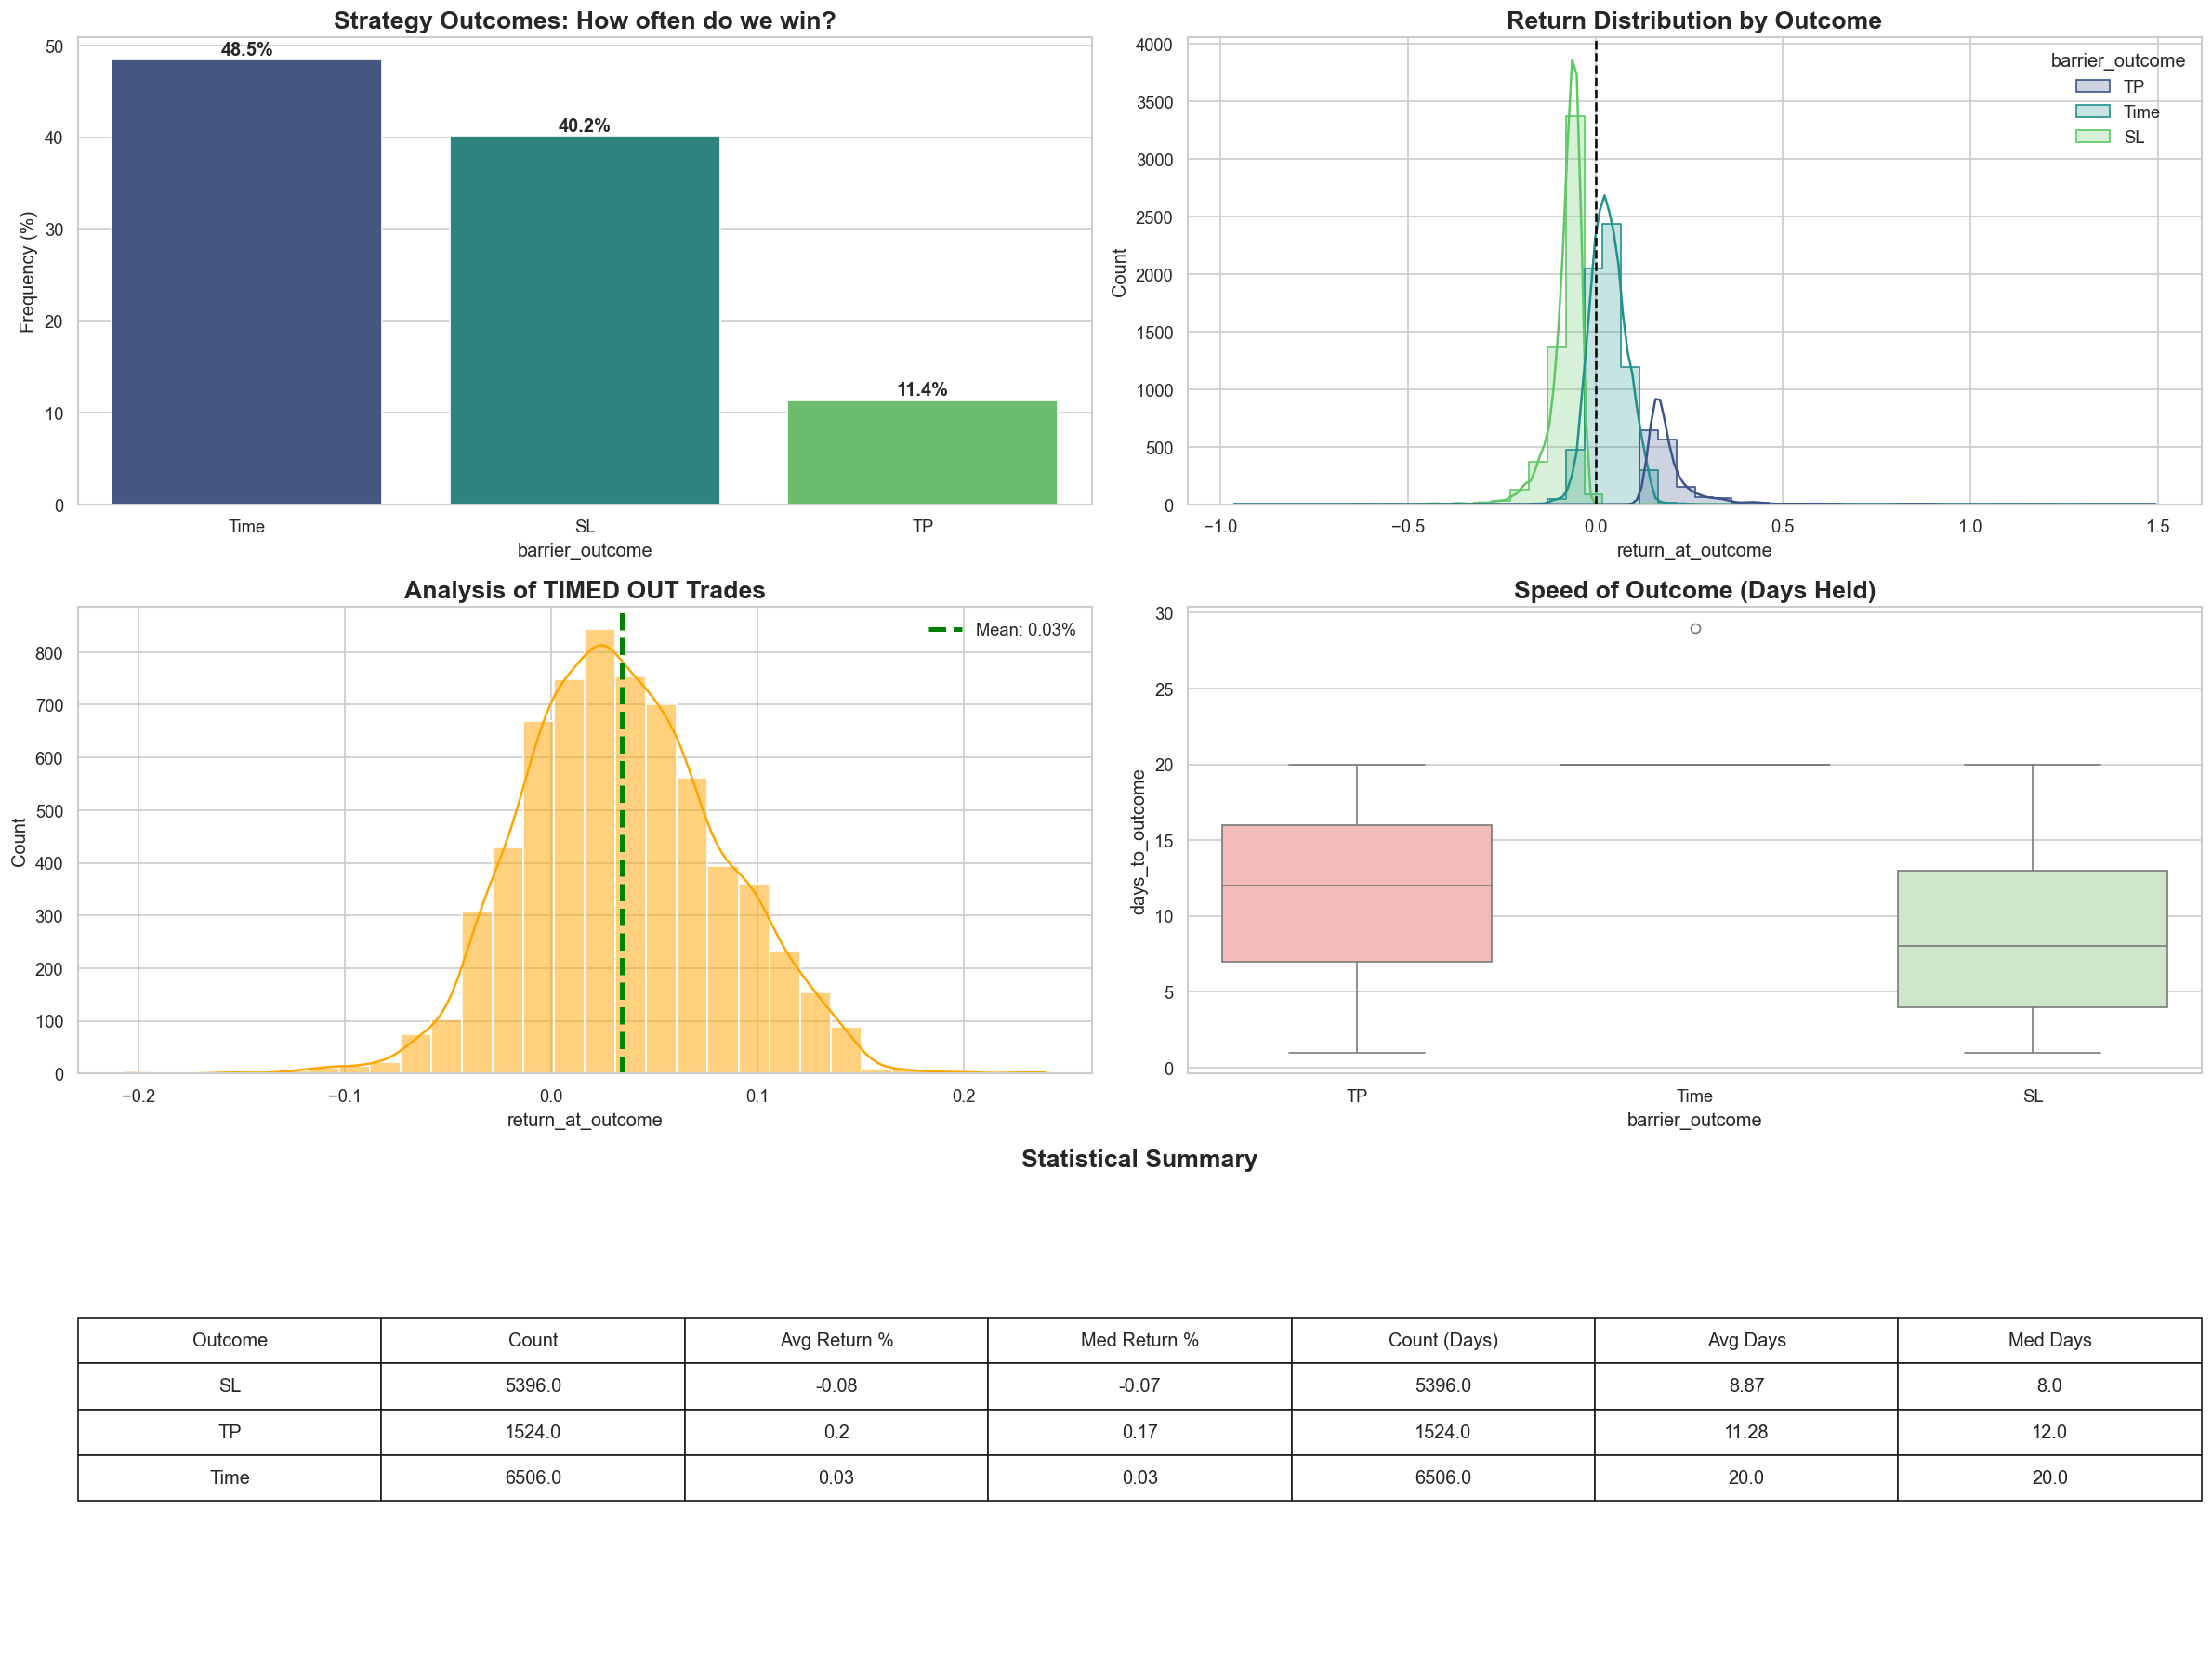

In [15]:
# --- CELL 2: Triple Barrier Strategy Deep Dive ---

def analyze_3bar(df):
    fig = plt.figure(figsize=(20, 15))
    gs = fig.add_gridspec(3, 2)
    
    # 1. Outcome Distribution (The Hit Rate)
    ax1 = fig.add_subplot(gs[0, 0])
    counts = df['barrier_outcome'].value_counts(normalize=True) * 100
    sns.barplot(x=counts.index, y=counts.values, ax=ax1, palette='viridis', hue=counts.index, legend=False)
    ax1.set_title("Strategy Outcomes: How often do we win?", fontsize=16, fontweight='bold')
    ax1.set_ylabel("Frequency (%)")
    for i, v in enumerate(counts.values):
        ax1.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

    # 2. Return Distribution (The Payoff Profile)
    ax2 = fig.add_subplot(gs[0, 1])
    sns.histplot(data=df, x='return_at_outcome', hue='barrier_outcome', bins=50, kde=True, ax=ax2, palette='viridis', element="step")
    ax2.set_title("Return Distribution by Outcome", fontsize=16, fontweight='bold')
    ax2.axvline(0, color='black', linestyle='--')

    # 3. The "Good Loser" Check (Time-Out Profitability)
    ax3 = fig.add_subplot(gs[1, 0])
    timed_out = df[df['barrier_outcome'] == 'Time']
    mean_to = timed_out['return_at_outcome'].mean()
    color_to = 'green' if mean_to > 0 else 'red'
    
    sns.histplot(data=timed_out, x='return_at_outcome', bins=30, color='orange', ax=ax3, kde=True)
    ax3.axvline(mean_to, color=color_to, linestyle='--', linewidth=3, label=f'Mean: {mean_to:.2f}%')
    ax3.set_title("Analysis of TIMED OUT Trades", fontsize=16, fontweight='bold')
    ax3.legend()

    # 4. Velocity (Days Held)
    ax4 = fig.add_subplot(gs[1, 1])
    sns.boxplot(data=df, x='barrier_outcome', y='days_to_outcome', ax=ax4, palette='Pastel1', hue='barrier_outcome', legend=False)
    ax4.set_title("Speed of Outcome (Days Held)", fontsize=16, fontweight='bold')

    # 5. Efficiency Table (Viz)
    ax5 = fig.add_subplot(gs[2, :])
    ax5.axis('off')
    
    # Create Summary Table
    summary = df.groupby('barrier_outcome')[['return_at_outcome', 'days_to_outcome']].agg(['count', 'mean', 'median']).round(2)
    table_data = []
    outcomes = summary.index.tolist()
    for outcome in outcomes:
        row = [outcome]
        row.extend(summary.loc[outcome, 'return_at_outcome'].values)
        row.extend(summary.loc[outcome, 'days_to_outcome'].values)
        table_data.append(row)
        
    cols = ['Outcome', 'Count', 'Avg Return %', 'Med Return %', 'Count (Days)', 'Avg Days', 'Med Days']
    table = ax5.table(cellText=table_data, colLabels=cols, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 2)
    ax5.set_title("Statistical Summary", fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.show()

analyze_3bar(df_3bar)

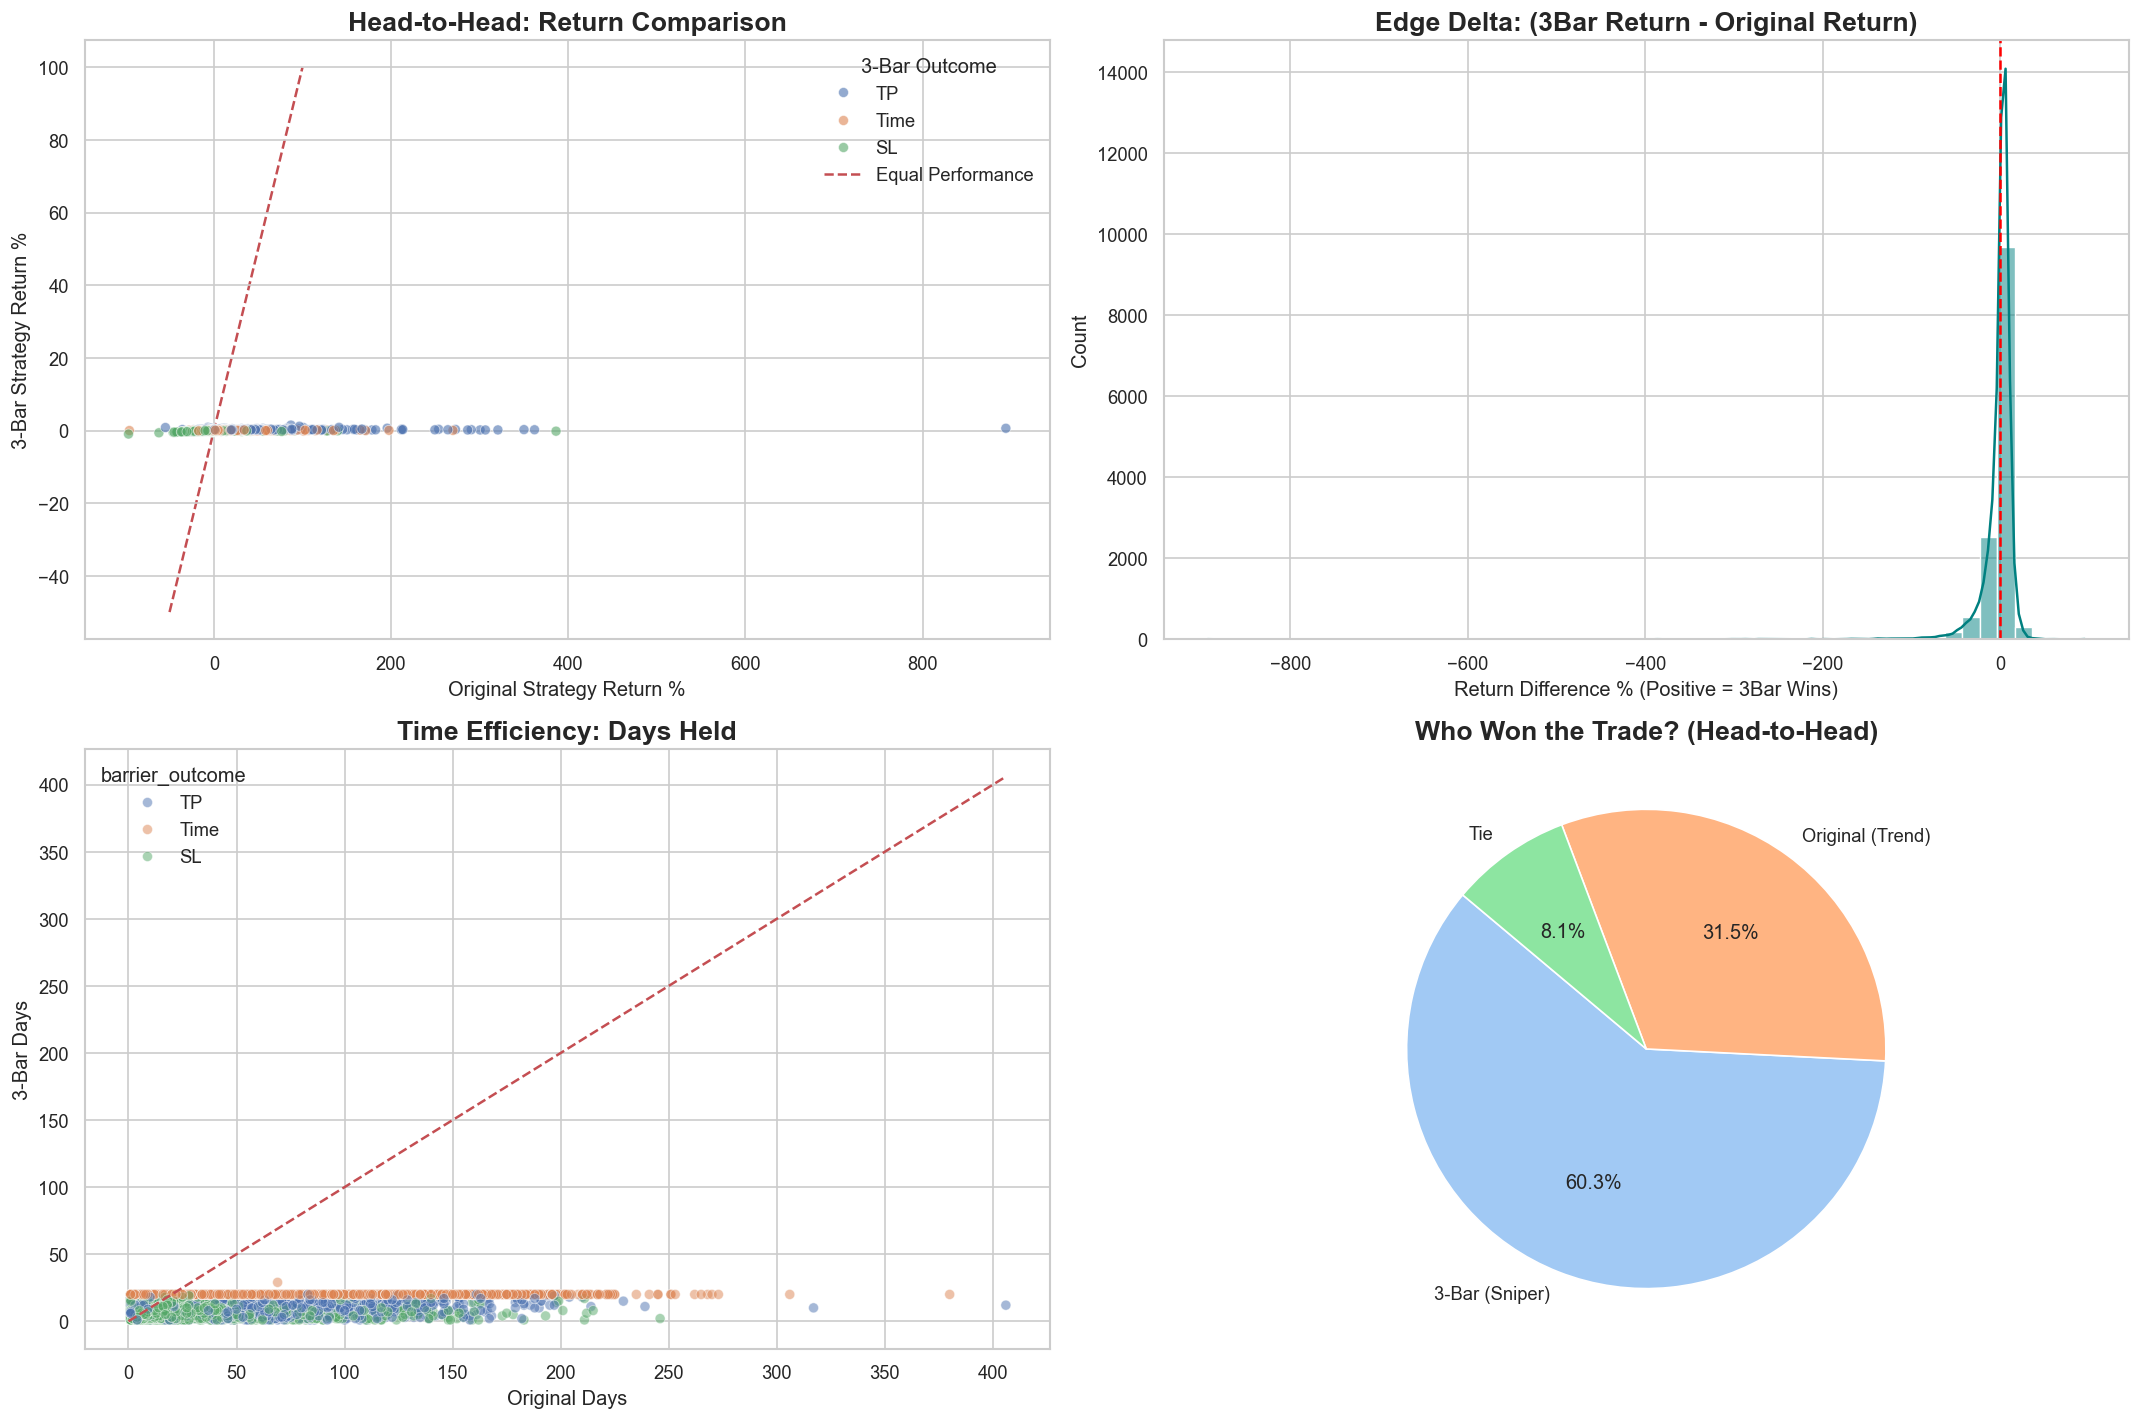

In [17]:
# --- CELL 3: Head-to-Head Comparison ---

def compare_strategies(df_old, df_new):
    # 1. Merge the dataframes
    merged = pd.merge(
        df_old[['trade_id', 'ticker', 'return_pct', 'days_held']],
        df_new[['trade_id', 'barrier_outcome', 'return_at_outcome', 'days_to_outcome']],
        on='trade_id',
        suffixes=('_orig', '_3bar')
    )
    
    # 2. Calculate Deltas
    merged['return_delta'] = merged['return_at_outcome'] - merged['return_pct']
    merged['days_delta'] = merged['days_to_outcome'] - merged['days_held']
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # A. Scatter: Old vs New Returns
    ax1 = axes[0, 0]
    sns.scatterplot(data=merged, x='return_pct', y='return_at_outcome', hue='barrier_outcome', alpha=0.6, ax=ax1, palette='deep')
    # Equal performance line
    ax1.plot([-50, 100], [-50, 100], 'r--', label='Equal Performance', zorder=0)
    ax1.set_title("Head-to-Head: Return Comparison", fontsize=16, fontweight='bold')
    ax1.set_xlabel("Original Strategy Return %")
    ax1.set_ylabel("3-Bar Strategy Return %")
    ax1.legend(title='3-Bar Outcome')
    
    # B. Performance Delta Histogram
    ax2 = axes[0, 1]
    sns.histplot(merged['return_delta'], bins=50, kde=True, color='teal', ax=ax2)
    ax2.axvline(0, color='red', linestyle='--')
    ax2.set_title("Edge Delta: (3Bar Return - Original Return)", fontsize=16, fontweight='bold')
    ax2.set_xlabel("Return Difference % (Positive = 3Bar Wins)")
    
    # C. Efficiency Scatter
    ax3 = axes[1, 0]
    sns.scatterplot(data=merged, x='days_held', y='days_to_outcome', hue='barrier_outcome', alpha=0.5, ax=ax3, palette='deep')
    ax3.plot([0, merged['days_held'].max()], [0, merged['days_held'].max()], 'r--', label='Equal Time')
    ax3.set_title("Time Efficiency: Days Held", fontsize=16, fontweight='bold')
    ax3.set_xlabel("Original Days")
    ax3.set_ylabel("3-Bar Days")
    
    # D. Win Rate Comparison
    ax4 = axes[1, 1]
    # Classify each trade
    merged['Winner'] = 'Tie'
    merged.loc[merged['return_delta'] > 1, 'Winner'] = '3-Bar (Sniper)'
    merged.loc[merged['return_delta'] < -1, 'Winner'] = 'Original (Trend)'
    
    counts = merged['Winner'].value_counts()
    ax4.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=140)
    ax4.set_title("Who Won the Trade? (Head-to-Head)", fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.show()
    
    return merged

# Run comparison and save the merged DF for tables
df_final = compare_strategies(df_orig, df_3bar)


FORENSIC ANALYSIS: SUPERPERFORMERS (> 50%)
Total Superperformers Identified: 247
Avg Return (Original): 98.6%
Avg Return (3-Bar):    0.2%
Avg Opportunity Cost:  -98.4% (Left on table)


C:\Users\Hang\AppData\Local\Temp\ipykernel_193024\1396453715.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='barrier_outcome', y='return_delta', data=runners, ax=axes[1], palette=colors)


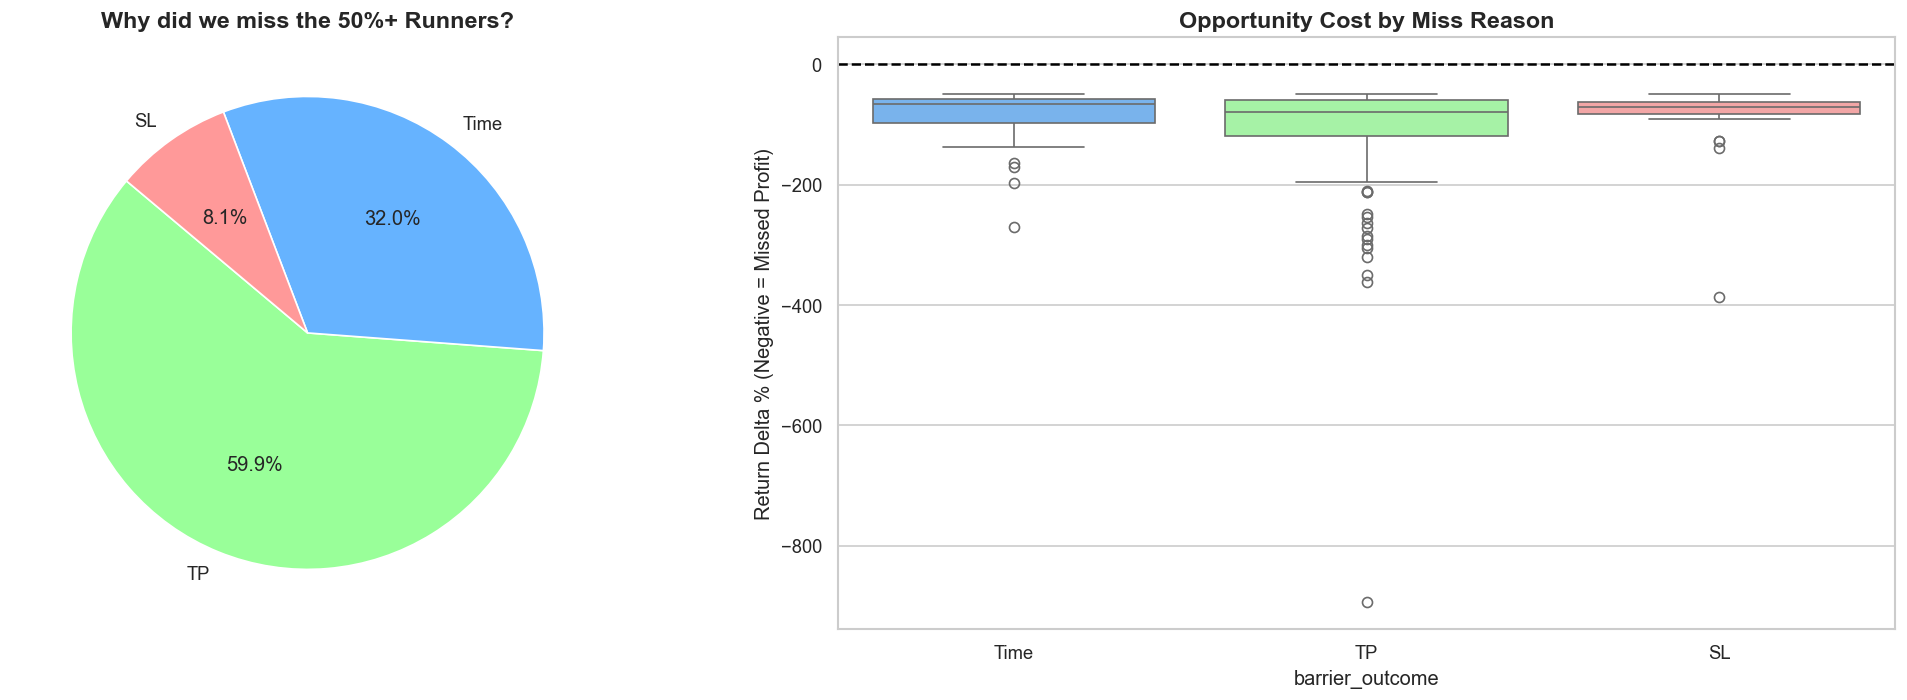


--- DIAGNOSIS & FIXES ---
❌ MAJOR ISSUE: CAPPED UPSIDE (59.9% of cases)
Diagnosis: Your model works perfectly! You picked the winners, but sold them for 20% while they went to 100%.
✅ FIX: Implement 'Hybrid Execution' (Sell 50% at Target, keep 50% with Trailing Stop).

--- TOP 5 MISSED OPPORTUNITIES ---


,ticker,barrier_outcome,return_pct,return_at_outcome,return_delta,days_held,days_to_outcome
4136,GME,TP,893.839836,0.611910,-893.227926,37,14
3631,RIOT,SL,386.180905,-0.178392,-386.359296,92,7
3838,MSTR,TP,361.893085,0.212359,-361.680726,93,6
12850,AEVA,TP,350.000000,0.251724,-349.748276,107,4
4168,ASTH,TP,320.571429,0.164675,-320.406753,214,11


In [19]:
# --- CELL 5: Forensic Analysis of Missed Superperformers ---

def analyze_missed_runners(df, threshold=50):
    """
    Investigates trades where the Original Strategy returned > threshold% (Superperformers),
    but the 3-Bar strategy captured significantly less.
    """
    print(f"\n{'='*60}")
    print(f"FORENSIC ANALYSIS: SUPERPERFORMERS (> {threshold}%)")
    print(f"{'='*60}")
    
    # 1. Isolate the Superperformers
    # These are trades where the stock ACTUALLY moved > 50% (validated by Original Strategy)
    runners = df[df['return_pct'] >= threshold].copy()
    
    if len(runners) == 0:
        print(f"No trades found with >{threshold}% return in Original Strategy.")
        return
    
    print(f"Total Superperformers Identified: {len(runners)}")
    print(f"Avg Return (Original): {runners['return_pct'].mean():.1f}%")
    print(f"Avg Return (3-Bar):    {runners['return_at_outcome'].mean():.1f}%")
    print(f"Avg Opportunity Cost:  {runners['return_delta'].mean():.1f}% (Left on table)")
    
    # 2. Categorize the "Miss" (Why did we miss it?)
    # Type A: Shakeout (Hit SL)
    # Type B: Patience (Hit Time)
    # Type C: Capped (Hit TP)
    reason_counts = runners['barrier_outcome'].value_counts()
    
    # 3. Visualize the Breakdown
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Chart 1: The "Why" Pie Chart
    # Use distinct colors for causes
    colors = {'SL': '#ff9999', 'Time': '#66b3ff', 'TP': '#99ff99'}
    
    axes[0].pie(reason_counts, labels=reason_counts.index, autopct='%1.1f%%', 
                startangle=140, colors=[colors.get(x, 'gray') for x in reason_counts.index])
    axes[0].set_title(f"Why did we miss the {threshold}%+ Runners?", fontsize=14, fontweight='bold')
    
    # Chart 2: The Cost of each Mistake
    sns.boxplot(x='barrier_outcome', y='return_delta', data=runners, ax=axes[1], palette=colors)
    axes[1].set_title("Opportunity Cost by Miss Reason", fontsize=14, fontweight='bold')
    axes[1].set_ylabel("Return Delta % (Negative = Missed Profit)")
    axes[1].axhline(0, color='black', linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    # 4. Strategic Recommendations based on Data
    print("\n--- DIAGNOSIS & FIXES ---")
    
    most_common_fail = reason_counts.idxmax()
    pct = (reason_counts.max() / len(runners)) * 100
    
    if most_common_fail == 'TP':
        print(f"❌ MAJOR ISSUE: CAPPED UPSIDE ({pct:.1f}% of cases)")
        print("Diagnosis: Your model works perfectly! You picked the winners, but sold them for 20% while they went to 100%.")
        print("✅ FIX: Implement 'Hybrid Execution' (Sell 50% at Target, keep 50% with Trailing Stop).")
        
    elif most_common_fail == 'SL':
        print(f"❌ MAJOR ISSUE: VOLATILITY SHAKEOUT ({pct:.1f}% of cases)")
        print("Diagnosis: Your stops are too tight. These stocks dipped -7% before going +50%.")
        print("✅ FIX: Switch from Fixed Stop (-7%) to ATR-based Stop (-2.5 ATR) or widen the stop slightly.")
        
    elif most_common_fail == 'Time':
        print(f"❌ MAJOR ISSUE: IMPATIENCE ({pct:.1f}% of cases)")
        print("Diagnosis: You entered too early. The stock drifted for 20 days, you sold, THEN it exploded.")
        print("✅ FIX: Improve 'Timing' features. Add 'Vol Contraction' or 'Catalyst' requirements to ensure immediate moves.")

    # 5. The "Gallery of Pain" (Top 5 Examples)
    print(f"\n--- TOP 5 MISSED OPPORTUNITIES ---")
    # Sort by biggest miss
    pain_gallery = runners.sort_values('return_delta', ascending=True).head(5)
    display(pain_gallery[['ticker', 'barrier_outcome', 'return_pct', 'return_at_outcome', 'return_delta', 'days_held', 'days_to_outcome']])

# Run the analysis
analyze_missed_runners(df_final, threshold=50)

# Feature Surgery
 - focus on velocity, remove fundamental/volatility, which are covered in M01

python model_trainer.py --steps d1 d2 d3 d3train --horizon 120 --feature-version M01_3BAR_V2 --tune --trials 50 --start 2018-01-01 --end 2025-12-31

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# --- CONFIGURATION ---
# Load the dataset with the CORRECT labels (TP=4, SL=1, Time=30)
DATA_PATH = '../data/ml/d3_triple_barrier_120d.parquet' 

# The "Kill List": Features to BAN prevents the model from cheating
# We remove Volatility (cheats via mechanics) and Fundamentals (cheats via value)
BANNED_FEATURES = [
    'nATR', 'ATR', 'natr', 'ATR_Lag1', 'nATR_Lag1',  # The "Volatility Trap"
    'pe_ratio', 'forward_pe', 'peg', 'ps_ratio',     # The "Value Trap"
    'operating_margin', 'net_margin', 'gross_margin', # Quality Metrics
    'eps_growth_yoy', 'revenue_growth_yoy',           # Growth Metrics
    'market_cap', 'fiscal_period', 'fiscal_date'      # Metadata
]

# Load Data
try:
    df = pd.read_parquet(DATA_PATH)
    print(f"✅ Loaded {len(df)} rows.")
except FileNotFoundError:
    print("⚠️ File not found. Make sure you generated 'd3_triple_barrier_30d_ignition.parquet'.")
    # Using your sample structure for demo purposes if file missing
    df = pd.DataFrame()

df.head(1)

✅ Loaded 9261 rows.


,trade_id,Date,Open,High,Low,Close,Volume,SMA_50,Price_vs_SMA_50,SMA_150,Price_vs_SMA_150,SMA_200,Price_vs_SMA_200,ATR,High_52W,Low_52W,Vol_MA,Vol_Ratio,High_20D,Breakout,RS,RS_MA,nATR,VCP_Ratio,Consolidation_Width,...,inventory_growth_yoy,inventory_vs_sales_spread,earnings_quality_score,fcf_margin,gross_margin_trend,days_since_report,days_since_earnings,is_stale,has_fundamentals,pe_ratio,ps_ratio,pb_ratio,peg_adjusted,is_declining_earnings,label,return_pct,days_held,exit_reason,y_meta,barrier_outcome,days_to_outcome,return_at_outcome,barrier_stop_pct,barrier_target_pct,barrier_time_days
0,1,2018-04-03,23.93,24.951,23.89,24.87,3900569,21.9116,13.501524,17.490067,42.194998,15.74935,57.911279,0.908636,24.87,8.89,2949744.1,1.322341,24.35,True,0.095371,0.078004,3.653541,0.858608,17.897065,...,NaN,NaN,3.388784,NaN,NaN,1.0,1.0,False,True,NaN,NaN,NaN,NaN,0,0,1.889827,49,trend_break,0,Time,20,0.021713,0.036535,0.2,20


In [14]:
def inject_physics_features(df):
    """
    Calculates pure 'Physics' metrics: Velocity and Acceleration.
    """
    df = df.copy()
    
    # 1. Immediate Thrust (2nd Derivative of Price)
    # Measures the acceleration of the price move itself.
    # Logic: (Today's Move) - (Yesterday's Move)
    df['immediate_thrust'] = df['Close'].diff(1).diff(1)
    
    # 2. Log Volume Velocity (Demand Surge)
    # Logic: Percentage change in volume force. Better than raw volume.
    # If volume doubles in 2 days, this spikes.
    df['log_volume_velocity'] = np.log(df['Volume'].replace(0, 1)).diff(2)
    
    # 3. Price Acceleration (10d Slope Change - derived from Alpha 046 logic)
    # Logic: Is the trend getting steeper? (New Slope - Old Slope)
    slope_new = (df['Close'] - df['Close'].shift(10)) / 10
    slope_old = (df['Close'].shift(10) - df['Close'].shift(20)) / 10
    df['price_accel_10d'] = slope_new - slope_old

    return df

print("Injecting Physics Features...")
df_eng = inject_physics_features(df)
print(f"Added: ['immediate_thrust', 'log_volume_velocity', 'price_accel_10d']")

Injecting Physics Features...
Added: ['immediate_thrust', 'log_volume_velocity', 'price_accel_10d']


In [19]:
FEATURES_TO_LAG = [
    'nATR', 'ATR', 'VCP_Ratio', 'Consolidation_Width',
    'Price_vs_SMA_50', 'Price_vs_SMA_150', 'Price_vs_SMA_200',
    'RS', 'RS_MA', 'Dry_Up_Volume',
    'High_52W', 'Low_52W', 'Lowest_Low_20D', 'Highest_High_20D',
    'RSI_14', 'Dist_From_52W_High', 'Dist_From_52W_Low', 'Dist_From_20D_Low', 'Dist_From_20D_High'
]

lag_features = [f"{f}_Lag1" for f in FEATURES_TO_LAG]
delta_features = [f"{feature}_Delta" for feature in FEATURES_TO_LAG]

# Get numeric features only
exclude_cols = ['date', 'ticker', 'label', 'return_pct', 'days_held', 'exit_reason', 'year']
raw_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'High_52W', 'Low_52W', 'ATR', 'Vol_MA', 'High_20D', 'ATR_Lag1', 
            'High_52W_Lag1', 'Low_52W_Lag1', 'is_stale', 'has_fundamentals', 'SMA_50', 'SMA_150', 'SMA_200', 'RS_MA']
delta_cols_drop = [
    # contraction
    'ATR_Delta', 'VCP_Ratio_Delta', 'Dist_From_52W_Low_Delta', 'Dist_From_20D_Low_Delta',
    # momentum
    'Highest_High_20D_Delta', 'High_52W_Delta', 'RS_MA_Delta',
    'nATR_Delta'
] 

price_structure = [
    'High_52W',
    'Low_52W',
    'Lowest_Low_20D',        # 20-day low value (needed for distance calc)
    'Highest_High_20D',      # 20-day high value (needed for distance calc)
    'High_20D',              # 20-day high (for breakout detection)
    'Lowest_Low_20D_Lag1',   # Lagged 20-day low value
    'Highest_High_20D_Lag1', # Lagged 20-day
]

# drop high corr cols
high_corr_cols = ['days_since_earnings', 'Price_vs_SMA_150', 'quick_ratio', 'RS_MA', 'net_margin', 'Consolidation_Width', 'gross_margin', 'gross_margin_trend', 'net_income_growth_yoy']
fundamental_cols = ['operatingCashFlow', 'freeCashFlow', 'netIncome', 'revenue']
low_importance = ['RSI_Regime', 'RSI_14']

labels = ['trade_id', 'y_meta', 'days_to_outcome', 'return_at_outcome', 'barrier_stop_pct', 'barrier_target_pct', 'barrier_time_days']

In [30]:
# --- CRITICAL FIXES ---

# 1. LEAKAGE (Future Data) - MUST DROP
target_leakage = [
    'y_meta', 
    'days_to_outcome', 
    'return_at_outcome', 
    'barrier_stop_pct', 
    'barrier_target_pct', 
    'barrier_time_days',
]

# 2. VOLATILITY TRAP (Force Velocity Learning)
volatility_cols = ['nATR', 'alpha060']  # nATR is the primary "cheat" feature

# 3. FUNDAMENTAL TRAP (Remove Value Investing Logic)
fundamental_ratios = [
    'pe_ratio', 'ps_ratio', 'pb_ratio', 'peg_adjusted',
    'revenue_growth_yoy', 'eps_growth_yoy', 'eps_accel', 'revenue_accel',
    'operating_margin', 'roe', 'roa', 'fcf_margin', 
    'debt_to_equity', 'current_ratio', 
    'earnings_quality_score', 'inventory_growth_yoy', 
    'inventory_vs_sales_spread', 'revenue_cagr_3y', 'eps_stability_score',
    'is_declining_earnings', 'days_since_report'
]

# 4. REDUNDANCY (Keep the strongest, drop the echoes)
redundant_deltas = [
    'Price_vs_SMA_50_Delta', 
    'Price_vs_SMA_150_Delta',
    'Price_vs_SMA_200_Delta' # We already have the main values
]

# Update your exclude list
exclude_cols = labels + volatility_cols + fundamental_ratios + exclude_cols + raw_cols + price_structure + high_corr_cols + delta_cols_drop + lag_features + fundamental_cols + low_importance

In [31]:
selected_features = [c for c in df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])]

print(f"Total numeric features: {len(selected_features)}")
print(f"\nAll cols: {selected_features[:]}")

Total numeric features: 42

All cols: ['Price_vs_SMA_50', 'Price_vs_SMA_200', 'Vol_Ratio', 'Breakout', 'RS', 'VCP_Ratio', 'Dry_Up_Volume', 'Dist_From_52W_High', 'Is_Green_Day', 'Green_Days_Ratio_20D', 'SMA_50_Slope', 'Dist_From_20D_Low', 'Dist_From_20D_High', 'Dist_From_52W_Low', 'rs_velocity', 'volume_acceleration', 'breakout_momentum', 'consolidation_duration', 'price_momentum_curve', 'Consolidation_Width_Delta', 'RS_Delta', 'Dry_Up_Volume_Delta', 'Low_52W_Delta', 'Lowest_Low_20D_Delta', 'RSI_14_Delta', 'Dist_From_52W_High_Delta', 'Dist_From_20D_High_Delta', 'alpha001', 'alpha006', 'alpha009', 'alpha012', 'alpha041', 'alpha101', 'alpha002', 'alpha004', 'alpha011', 'alpha013', 'alpha015', 'alpha054', 'alpha046', 'alpha049', 'alpha051']



--- TOP 15 PREDICTORS OF IGNITION ---


c:\Users\Hang\PycharmProjects\quantamental\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,Feature,Win_Mean,Lose_Mean,Separation_Score (T-Stat)
4,RS,0.140996,0.274999,14.449266
31,alpha041,49.532491,97.827316,14.270786
35,alpha011,0.727546,0.392649,14.256653
11,Dist_From_20D_Low,0.293578,0.179098,9.985320
1,Price_vs_SMA_200,48.259194,26.486122,9.691831
38,alpha054,-0.597516,-0.667397,8.974211
0,Price_vs_SMA_50,18.432318,10.900901,8.628468
7,Dist_From_52W_High,-4.175490,-2.091148,7.463324
12,Dist_From_20D_High,-0.018110,-0.010472,6.213092
20,RS_Delta,0.080222,0.043570,6.014263


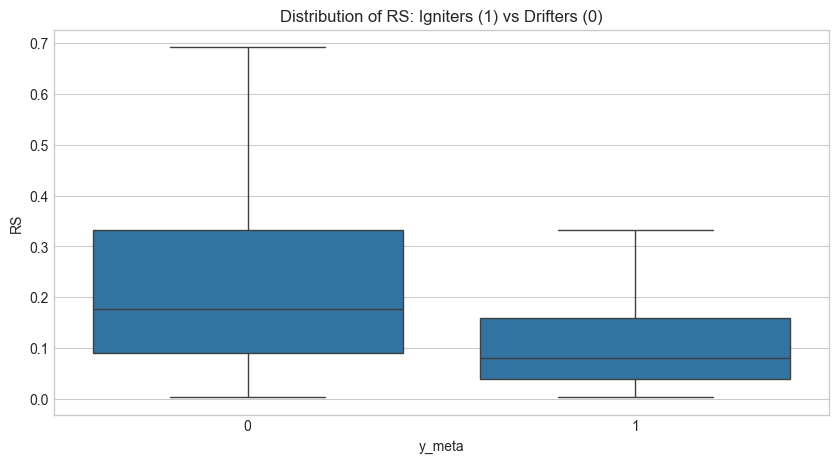

In [32]:
# Define Winners (Igniters) vs Losers (Drifters)
igniters = df_eng[df_eng['y_meta'] == 1]
drifters = df_eng[df_eng['y_meta'] == 0]

results = []

for feature in selected_features:
    # Drop NaNs for calculation
    val_win = igniters[feature].dropna()
    val_lose = drifters[feature].dropna()
    
    if len(val_win) < 10 or len(val_lose) < 10: continue
    
    # Calculate Separation
    mean_win = val_win.mean()
    mean_lose = val_lose.mean()
    t_stat, p_val = ttest_ind(val_win, val_lose, equal_var=False)
    
    results.append({
        'Feature': feature,
        'Win_Mean': mean_win,
        'Lose_Mean': mean_lose,
        'Separation_Score (T-Stat)': abs(t_stat) # Higher is better
    })

# Show Top 15 Predictors of Ignition
df_results = pd.DataFrame(results).sort_values('Separation_Score (T-Stat)', ascending=False)

print("\n--- TOP 15 PREDICTORS OF IGNITION ---")
display(df_results.head(15))

# Visual Check: Plot the #1 Feature
best_feature = df_results.iloc[0]['Feature']
plt.figure(figsize=(10, 5))
sns.boxplot(x='y_meta', y=best_feature, data=df_eng, showfliers=False)
plt.title(f"Distribution of {best_feature}: Igniters (1) vs Drifters (0)")
plt.show()

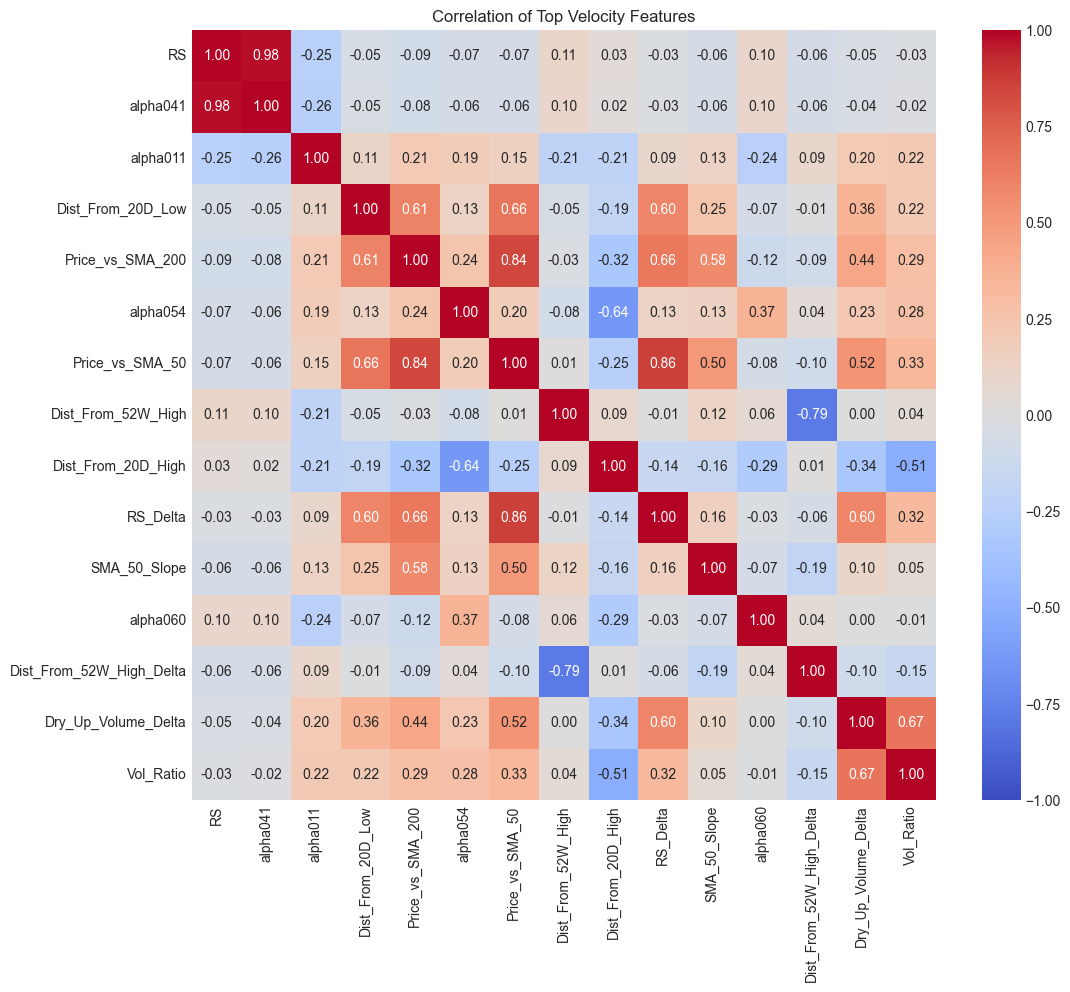


--- OPTIMIZATION RECOMMENDATIONS ---
⚔️ CLASH: alpha041 vs RS
   -> KEEP: RS (Score: 14.45)
   -> DROP: alpha041 (Score: 14.27)
⚔️ CLASH: RS_Delta vs Price_vs_SMA_50
   -> KEEP: Price_vs_SMA_50 (Score: 8.63)
   -> DROP: RS_Delta (Score: 6.01)


In [28]:
# Get Top 15 Features
top_features = df_results['Feature'].head(15).tolist()

# Check Correlation
corr_matrix = df_eng[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation of Top Velocity Features")
plt.show()

# Recommendation Engine
print("\n--- OPTIMIZATION RECOMMENDATIONS ---")
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            feat_a = corr_matrix.columns[i]
            feat_b = corr_matrix.columns[j]
            
            # Find which one is better
            score_a = df_results[df_results['Feature'] == feat_a]['Separation_Score (T-Stat)'].values[0]
            score_b = df_results[df_results['Feature'] == feat_b]['Separation_Score (T-Stat)'].values[0]
            
            winner = feat_a if score_a > score_b else feat_b
            loser = feat_b if score_a > score_b else feat_a
            
            print(f"⚔️ CLASH: {feat_a} vs {feat_b}")
            print(f"   -> KEEP: {winner} (Score: {max(score_a, score_b):.2f})")
            print(f"   -> DROP: {loser} (Score: {min(score_a, score_b):.2f})")

In [29]:
# Check for Zero Variance (The "Flatlines")
zero_var_cols = []
for col in df_eng.columns:
    if df_eng[col].dtype in ['float64', 'float32', 'int64']:
        # Check standard deviation
        if df_eng[col].std() == 0:
            zero_var_cols.append(col)
        # Check if nearly constant (e.g. 99.9% of rows are 0)
        elif df_eng[col].value_counts(normalize=True).iloc[0] > 0.99:
             print(f"⚠️ NEARLY FLAT: {col} ({df_eng[col].value_counts(normalize=True).iloc[0]*100:.2f}% same value)")

print(f"DEAD FEATURES (Zero Variance): {zero_var_cols}")

⚠️ NEARLY FLAT: barrier_time_days (99.92% same value)
DEAD FEATURES (Zero Variance): ['RSI_Regime']
